Training Hand Gesture Recognition Model...
Model training completed successfully!

--- Final Task Classification Report ---
              precision    recall  f1-score   support

        Palm       1.00      1.00      1.00         4
  Peace Sign       1.00      1.00      1.00         4
   Thumbs Up       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Overall Recognition Accuracy: 100.00%



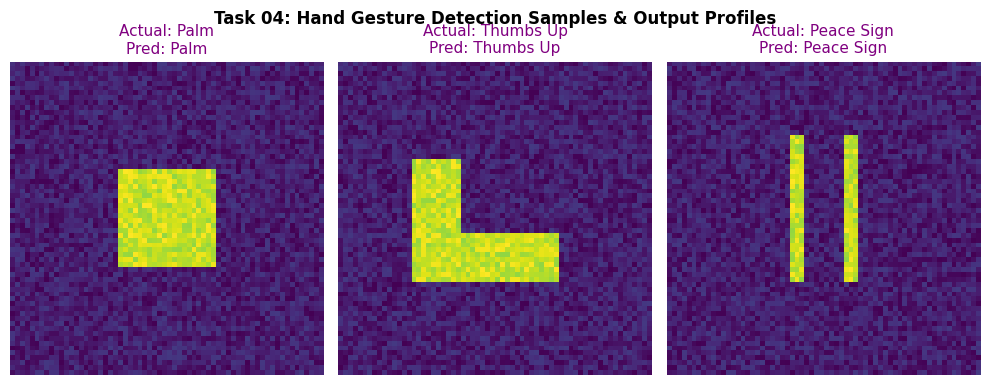

In [1]:
# ==========================================================
# TASK 04: Hand Gesture Recognition and Classification
# Repository Naming Format: SCT_ML_4
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Simulate structural hand gesture dataset data arrays
# We will create 3 gestures: 0 (Palm), 1 (Peace Sign), 2 (Thumbs Up)
np.random.seed(42)
num_samples = 60
grid_size = 64
pixel_features = grid_size * grid_size

X_gestures = []
y_labels = []

for i in range(num_samples):
    img = np.zeros((grid_size, grid_size))

    if i < 20:
        # Gesture 0: Palm (Central massive box structure)
        img[22:42, 22:42] = 1.0
        y_labels.append(0)
    elif i < 40:
        # Gesture 1: Peace Sign (Two distinct vertical bar structures)
        img[15:45, 25:28] = 1.0
        img[15:45, 36:39] = 1.0
        y_labels.append(1)
    else:
        # Gesture 2: Thumbs Up (L-shape corner block structure)
        img[35:45, 15:45] = 1.0
        img[20:45, 15:25] = 1.0
        y_labels.append(2)

    # Add minor data variances to simulate natural camera noise
    img += np.random.rand(grid_size, grid_size) * 0.2
    X_gestures.append(img.flatten())

X_gestures = np.array(X_gestures)
y_labels = np.array(y_labels)

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_gestures, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 3. Train a Random Forest Classifier
print("Training Hand Gesture Recognition Model...")
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
print("Model training completed successfully!\n")

# 4. Run model predictions on the testing split
y_pred = model.predict(X_test)

# 5. Output Precision Performance Metrics
gesture_names = ['Palm', 'Peace Sign', 'Thumbs Up']
print("--- Final Task Classification Report ---")
print(classification_report(y_test, y_pred, target_names=gesture_names))
print(f"Overall Recognition Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 6. Visualize Sample Structural Gestures and Predictions
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    sample_matrix = X_test[i].reshape(grid_size, grid_size)
    ax.imshow(sample_matrix, cmap='viridis')
    ax.set_title(f"Actual: {gesture_names[y_test[i]]}\nPred: {gesture_names[y_pred[i]]}", fontsize=11, color='purple')
    ax.axis('off')

plt.suptitle("Task 04: Hand Gesture Detection Samples & Output Profiles", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()